# Analyse

Identifier les principaux postes de dépense par service et par région, et repérer les ressources qui coûtent cher mais qui sont peu utilisées.

## 1. Chargement

In [19]:
import pandas as pd

df = pd.read_csv("../data/processed/gcp_costs_clean.csv", parse_dates=["usage_start", "usage_end"])
df.head()

,resource_id,service,usage_quantity,usage_unit,region,cpu_util_pct,memory_util_pct,net_in_bytes,net_out_bytes,usage_start,usage_end,cost_per_quantity,cost_usd,duree_jours
0,res-ST6BAJ2N,Cloud Dataproc,954.9843,Requests,europe-north1,92.72,70.42,77097035547,8.268593e+10,2024-08-01 22:24:00,2024-08-07 06:54:00,5.24,5004.12,5.354167
1,res-TYGNR0RV,Pub/Sub,479.6348,GB,europe-west1,37.78,46.80,8239357017,1.135149e+10,2024-08-23 09:18:00,2024-08-25 07:26:00,9.82,4710.01,1.922222
2,res-S3I9C869,BigQuery,114.4129,GB,southamerica-east1,82.54,59.47,23358691883,2.345081e+10,2024-07-18 11:13:00,2024-07-22 00:45:00,7.37,843.22,3.563889
3,res-1RY9BZ6G,Cloud Endpoints,413.1930,GB,us-central1,86.68,97.63,53404385778,6.078019e+10,2024-07-20 00:15:00,2024-07-21 10:16:00,4.41,1822.18,1.417361
4,res-S3HQYIZ2,Cloud Spanner,335.9892,GB,asia-southeast1,82.95,21.58,10795270461,1.416138e+10,2024-08-21 21:25:00,2024-08-25 00:21:00,6.09,2046.17,3.122222


## 2. Coûts par service

In [20]:
cost_by_service = df.groupby("service")["cost_usd"].sum().sort_values(ascending=False)
cost_by_service

service
Cloud CDN               141420.87
Cloud Build             135186.56
Pub/Sub                 128869.43
Cloud NAT               118601.48
Cloud Storage           117471.22
Cloud Endpoints         113136.97
Firestore               105440.23
Cloud Memorystore       104689.07
Cloud Dataproc          104540.83
Cloud SQL               101202.05
Cloud VPN               100648.30
Cloud Armor              98931.90
Cloud Load Balancing     98834.05
Cloud VPC                98099.65
BigQuery                 97995.99
Cloud Interconnect       92473.47
Cloud Spanner            89282.23
Container Registry       85370.73
Cloud Data Fusion        83777.36
Cloud Run                24800.86
Compute Engine           24278.50
Kubernetes Engine        19617.50
AI Platform              18377.48
Cloud Functions          17199.98
Dataflow                 14968.42
Name: cost_usd, dtype: float64

<Axes: title={'center': 'Coût total par service (USD)'}, ylabel='service'>

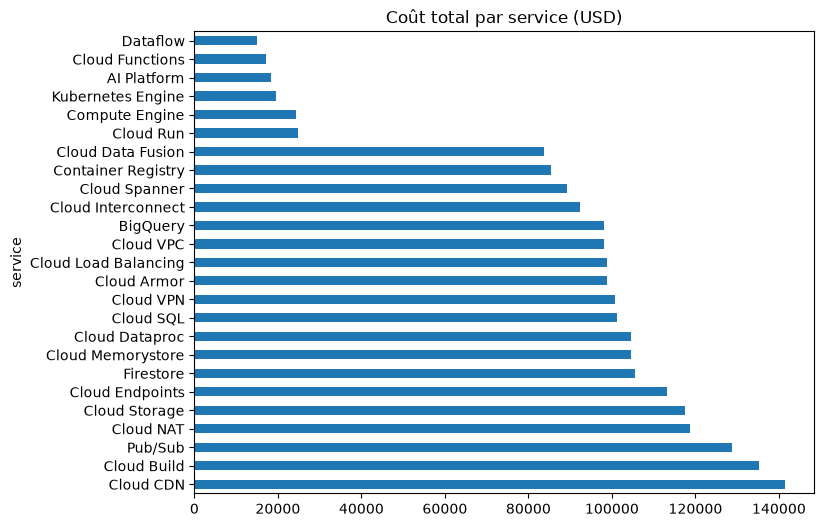

In [21]:
cost_by_service.plot(kind="barh", figsize=(8, 6), title="Coût total par service (USD)")

## 3. Coûts par région

In [22]:
cost_by_region = df.groupby("region")["cost_usd"].sum().sort_values(ascending=False)
cost_by_region

region
us-east1                   215617.01
southamerica-east1         214089.38
europe-west1               196151.05
europe-west3               191344.16
europe-north1              185261.26
asia-east1                 179106.41
asia-southeast1            178356.45
northamerica-northeast1    166861.29
australia-southeast1       160539.09
asia-northeast1            155778.73
us-central1                154223.28
us-west1                   137887.02
Name: cost_usd, dtype: float64

<Axes: title={'center': 'Coût total par région (USD)'}, ylabel='region'>

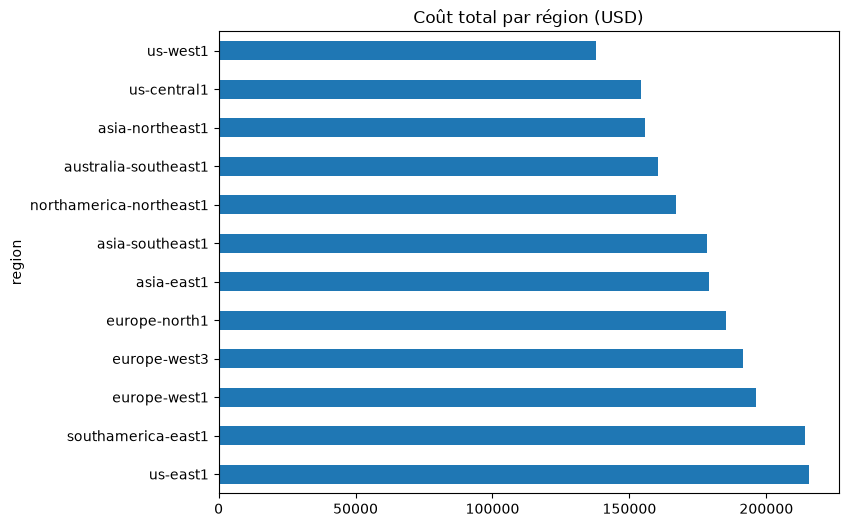

In [23]:
cost_by_region.plot(kind="barh", figsize=(8, 6), title="Coût total par région (USD)")

## 4. Détection de gaspillage

On considère qu'une ressource est un candidat au gaspillage si son coût est dans le quartile supérieur (top 25% des coûts) et que son utilisation (CPU ou mémoire) est dans le quartile inférieur (bottom 25%) : on paie cher pour une ressource peu utilisée.

In [24]:
cost_threshold = df["cost_usd"].quantile(0.75)
cpu_threshold = df["cpu_util_pct"].quantile(0.25)

print(f"Seuil coût (top 25%) : {cost_threshold:.2f} USD")
print(f"Seuil CPU (bottom 25%) : {cpu_threshold:.2f} %")

Seuil coût (top 25%) : 3257.32 USD
Seuil CPU (bottom 25%) : 26.74 %


In [25]:
waste_candidates = df[(df["cost_usd"] >= cost_threshold) & (df["cpu_util_pct"] <= cpu_threshold)]
print(f"Ressources candidates au gaspillage : {len(waste_candidates)}")

Ressources candidates au gaspillage : 66


In [26]:
waste_candidates.sort_values("cost_usd", ascending=False)[
    ["resource_id", "service", "region", "cost_usd", "cpu_util_pct", "memory_util_pct"]
]

,resource_id,service,region,cost_usd,cpu_util_pct,memory_util_pct
240,res-LWGX075A,Cloud Dataproc,southamerica-east1,8832.79,7.35,60.67
548,res-RUL6UJ2I,Cloud NAT,asia-southeast1,8750.60,8.79,61.74
859,res-723DJQ6D,Cloud Data Fusion,asia-northeast1,8693.36,7.96,10.82
268,res-QZVTIOPY,Cloud Storage,asia-east1,8437.53,17.08,91.07
594,res-7LLUZT3G,Cloud Endpoints,europe-north1,7989.93,21.58,24.91
...,...,...,...,...,...,...
545,res-DXKGGUD7,Cloud SQL,asia-east1,3368.17,0.69,57.08
783,res-W8GT53T9,Cloud NAT,us-west1,3359.84,6.07,48.18
818,res-FGBS0WGH,Cloud Build,northamerica-northeast1,3356.78,12.45,61.62
709,res-MHUZ0UCB,Cloud NAT,southamerica-east1,3312.85,25.50,89.97


In [27]:
waste_candidates["service"].value_counts()

service
Cloud NAT               6
Cloud Endpoints         6
Cloud VPC               5
Pub/Sub                 4
Cloud Spanner           4
BigQuery                4
Cloud Storage           4
Cloud CDN               4
Firestore               4
Cloud Interconnect      4
Cloud SQL               4
Cloud Data Fusion       3
Cloud Load Balancing    3
Cloud Memorystore       3
Cloud Dataproc          2
Cloud Armor             2
Cloud VPN               2
Cloud Build             2
Name: count, dtype: int64

## Synthèse

- Le service qui coûte le plus cher au total, c'est **Cloud CDN** (141 420 $), suivi de Cloud Build et Pub/Sub
- La région qui coûte le plus cher, c'est **us-east1** (215 617 $), suivie de southamerica-east1 et europe-west1
- **66 ressources** coûtent cher tout en étant à peine utilisées (CPU très faible) : c'est du gaspillage potentiel
- Le pire exemple : un Cloud Dataproc en southamerica-east1 qui coûte 8833 $ pour seulement 7% de CPU utilisé
- Ce gaspillage n'est pas lié à un service en particulier, il est réparti un peu partout (Cloud NAT et Cloud Endpoints reviennent le plus souvent)